## Model 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("practise.csv")
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_Years,Distance_City_km,Parking,Floor,Income_Area_Lakh,House_Price
0,850,2,1,15,12,0,1,4.5,32
1,900,2,2,12,10,1,2,5.0,38
2,950,2,2,10,9,1,3,5.2,42
3,1000,3,2,8,8,1,2,5.8,48
4,1050,3,2,7,7,1,4,6.0,52


In [15]:
df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]
df.drop(columns=["Bedrooms","Bathrooms","Parking"],inplace=True)
df.head()

,Area_sqft,Age_Years,Distance_City_km,Floor,Income_Area_Lakh,House_Price,Total_Rooms
0,850,15,12,1,4.5,32,3
1,900,12,10,2,5.0,38,4
2,950,10,9,3,5.2,42,4
3,1000,8,8,2,5.8,48,5
4,1050,7,7,4,6.0,52,5


In [16]:
import seaborn as sns

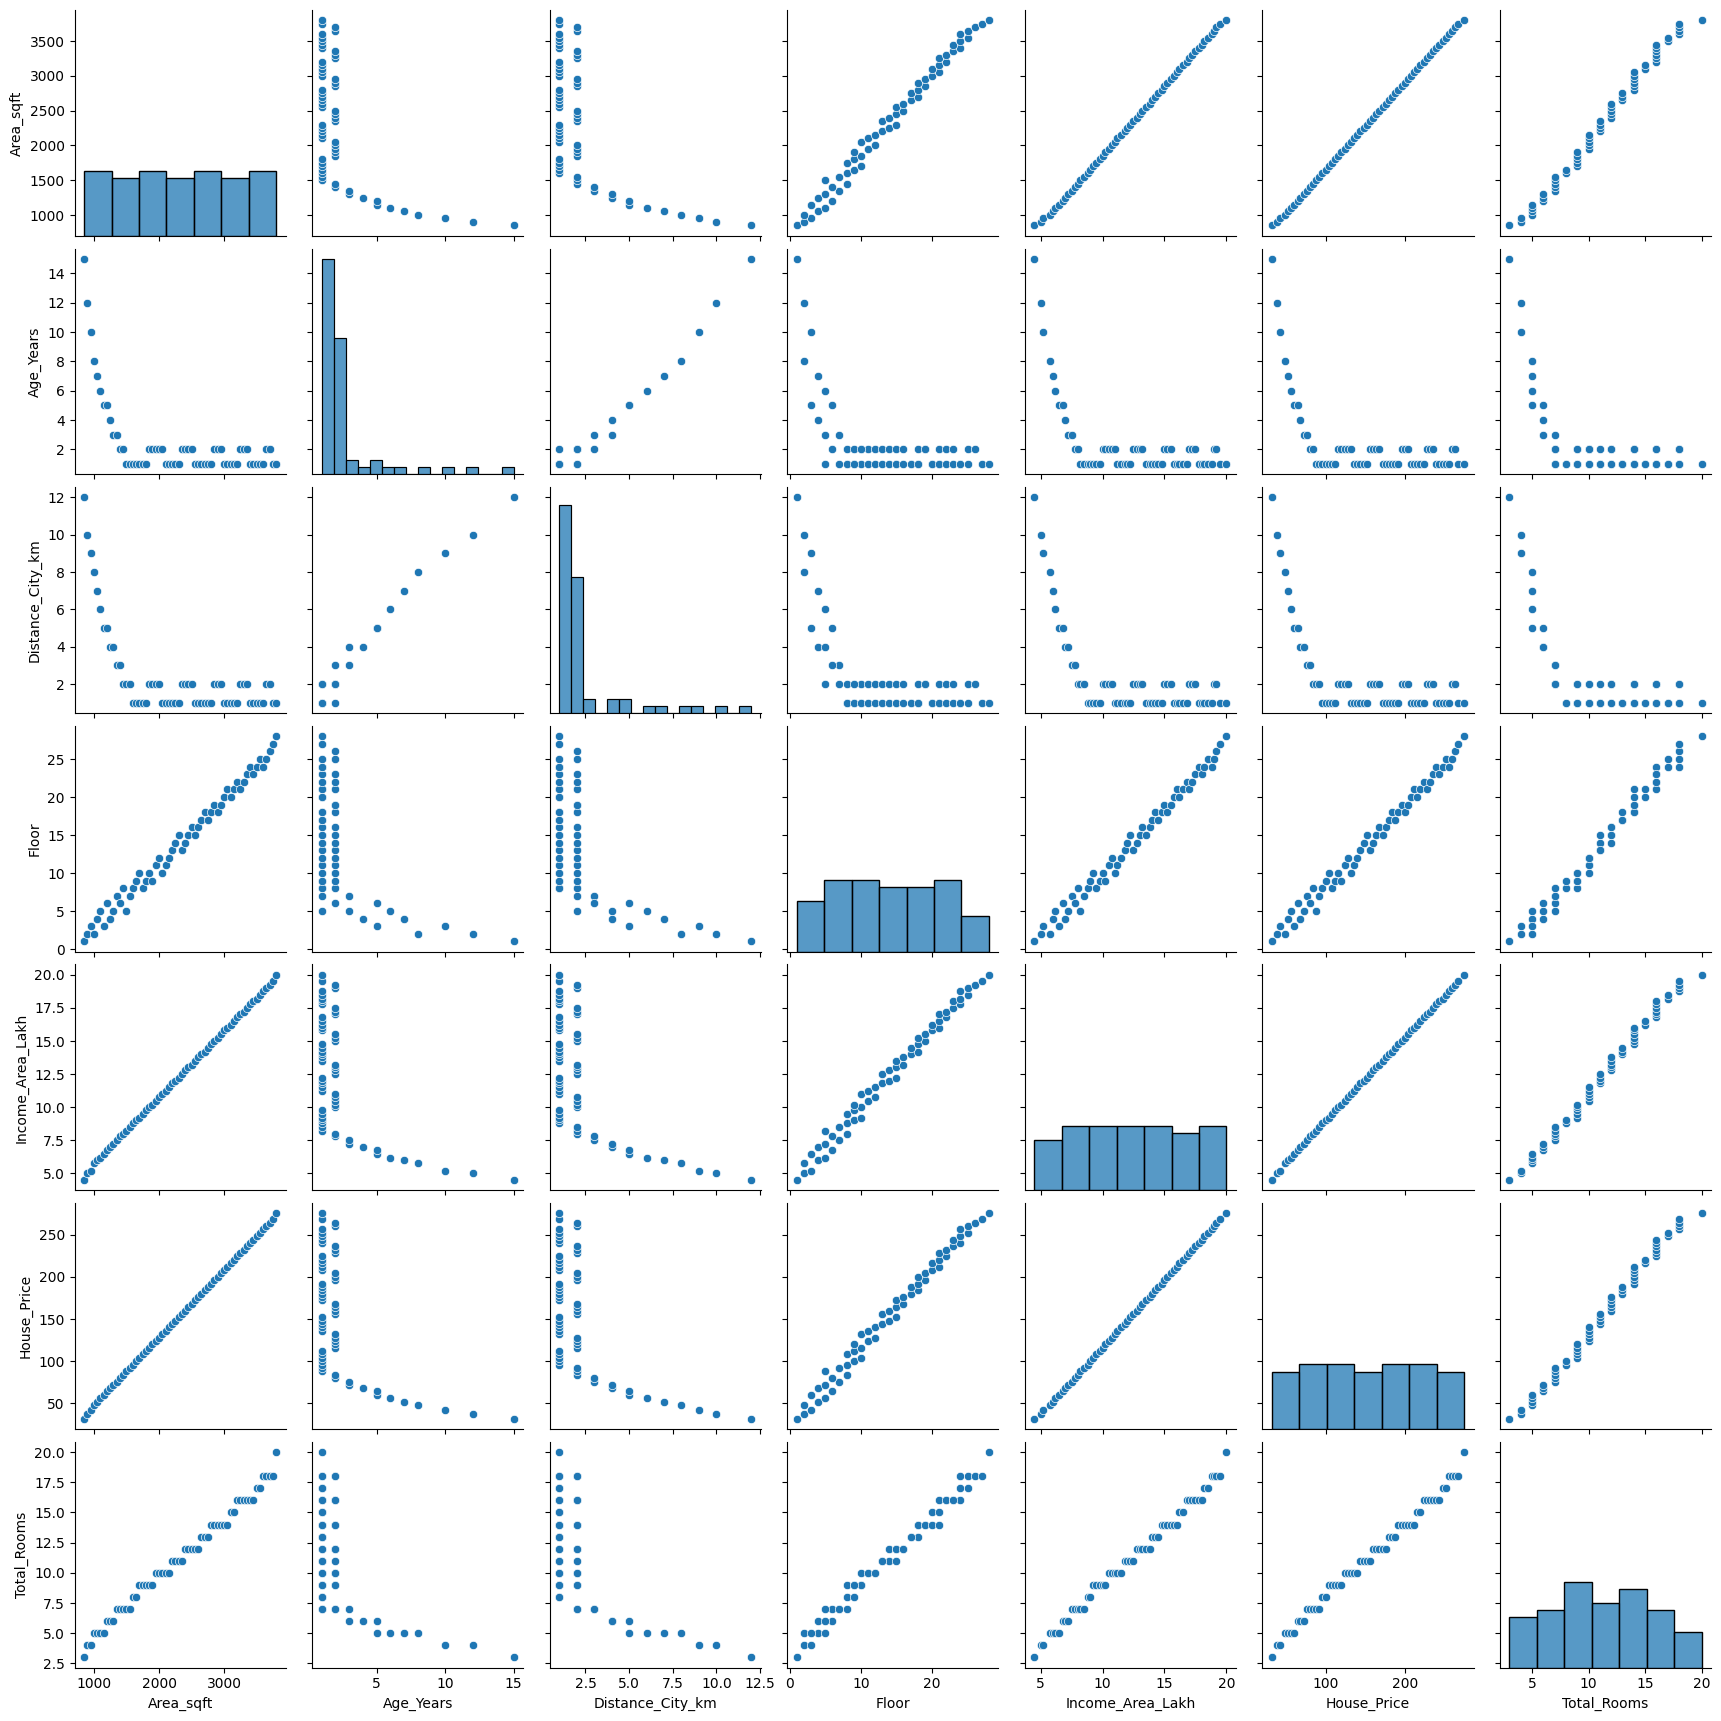

In [17]:
sns.pairplot(df)

In [18]:
df.corr()

,Area_sqft,Age_Years,Distance_City_km,Floor,Income_Area_Lakh,House_Price,Total_Rooms
Area_sqft,1.000000,-0.589290,-0.638250,0.993733,0.999802,0.999950,0.995145
Age_Years,-0.589290,1.000000,0.986569,-0.578827,-0.600055,-0.594372,-0.610082
Distance_City_km,-0.638250,0.986569,1.000000,-0.627214,-0.647507,-0.642514,-0.657249
Floor,0.993733,-0.578827,-0.627214,1.000000,0.993744,0.993869,0.991283
Income_Area_Lakh,0.999802,-0.600055,-0.647507,0.993744,1.000000,0.999931,0.996012
House_Price,0.999950,-0.594372,-0.642514,0.993869,0.999931,1.000000,0.995656
Total_Rooms,0.995145,-0.610082,-0.657249,0.991283,0.996012,0.995656,1.000000


In [19]:
X = df[[
    "Area_sqft",
    "Total_Rooms",
    "Age_Years",
    "Distance_City_km",
    "Floor",
    "Income_Area_Lakh"
]]

In [23]:
Y = df["House_Price"]

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.20,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [32]:
from sklearn.linear_model import LinearRegression
regression= LinearRegression()

In [33]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[41.38, 0.88,-0.36, 0.35, 0.47,23.89]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,150.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[15.51, 6.78, 0.78, 0.64, 0.58, 0.06]"


In [34]:
y_pred = regression.predict(X_test)
y_pred

array([ 34.99789363,  54.53977078, 159.93243007, 190.16503013,
        81.52600253, 220.99231565, 149.49495077, 200.64467054,
        78.51511334, 230.98942552, 193.79010576, 207.41229127])

In [35]:
from sklearn.metrics import mean_absolute_error , mean_squared_error
mse = mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

483.2841958980277
18.91631560503512
21.98372570557656


In [36]:
## R2 value 
from sklearn.metrics import r2_score
score = r2_score(Y_test,y_pred)
print(score)

## Adjusted R2 value 
print(1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))

0.9217761714430213
0.8279075771746468


In [40]:
regression.predict(scaler.transform([[850,4,10,7,5,5.5,]]))

c:\Users\Manis\OneDrive\vs COdE Python\Data-Science-Journey\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([40.12012458])

## Model 2